# CNN for Image Recognition: Classifying Natural Scenes

Authors: Alex Fried and Wyatt Lindseth

Date: October 5, 2025

## 1. Problem Statement

The goal of this project is to design, build, and train a Convolutional Neural Network (CNN) to classify images of natural scenes. The model will be trained on a labeled dataset and then evaluated on its ability to correctly identify the category of a scene from a separate test set of images. This task is a classic example of multi-class image classification, a fundamental problem in computer vision.

## 2. The Dataset

For this project, I have selected the "Intel Image Classification" dataset, available on Kaggle.

- Description: This dataset contains around 25,000 images of natural scenes from around the world. The images are categorized into 6 distinct classes:

    - buildings

    - forest

    - glacier

    - mountain

    - sea

    - street

- Data Split: The data is pre-divided into a training set (seg_train) with approximately 14,000 images, a testing set (seg_test) with approximately 3,000 images, and a prediction set (seg_pred) with approximately 7,000 images. For this project, we will use the seg_train folder for training and the seg_test folder for validation and evaluation.
- Image Properties: The images are RGB color images with a resolution of 150x150 pixels.

My CNN will be trained to recognize and classify a given image into one of these six categories.

## 3. Algorithm of the Solution

The solution follows a standard machine learning workflow for building a deep learning image classifier:

### 1: Environment Setup: 

- Import all necessary libraries, including TensorFlow, Keras, NumPy, and Matplotlib.

### 2: Data Preparation:

- Set up paths to the training and testing image directories.
- Use Keras's ImageDataGenerator to load images from the directories. This will handle image resizing (to a uniform 150x150) and normalization (scaling pixel values from 0-255 to 0-1).
- Create data batches for training and validation.

### 3: CNN Model Architecture:

- Initialize a sequential Keras model.
- Add a stack of three Convolutional layers, each followed by a Max Pooling layer. The number of filters in the convolutional layers will increase (32, 64, 128) to learn progressively more complex features.
- Flatten the output from the convolutional base into a 1-D vector.
- Add a fully connected (Dense) layer to perform high-level reasoning.
- Add the final output layer with a softmax activation function to produce a probability distribution over the 6 classes.

### 4: Model Compilation & Training:

- Compile the model using the adam optimizer, categorical_crossentropy loss function, and accuracy as the evaluation metric.
- Train the model on the training data for 50 epochs, while monitoring its performance on the validation data.

### 5: Evaluation and Analysis:

- Evaluate the final model's performance on the test dataset to get the final loss and accuracy.
- Plot the training and validation accuracy and loss curves over epochs to visualize the learning process and check for overfitting.
- Summarize the model's performance and its ability to classify natural scenes.

## 4. Implementation

Before running the code, ensure you have the necessary libraries installed.

In [12]:
!pip install tensorflow numpy matplotlib seaborn scipy

### 4.1 Import Libraries
First, we import all the necessary packages for data handling, model building, and visualization.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### 4.2 Data Loading and Preprocessing

We'll use ImageDataGenerator to efficiently load our image data from directories. It automatically resizes images and scales pixel values to the [0, 1] range, which is standard practice for neural networks.

In [ ]:
# Define paths to the dataset
# Note: You will need to download the dataset and update these paths accordingly.
base_dir = './Intel_Image_Classification/'
train_dir = os.path.join(base_dir, 'seg_train/seg_train')
validation_dir = os.path.join(base_dir, 'seg_test/seg_test')

# Image dimensions
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Create an ImageDataGenerator for training data (with rescaling)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Create an ImageDataGenerator for validation data (with rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches using train_datagen generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # For multi-class classification
)

# Flow validation images in batches using validation_datagen generator
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Configure the Early Stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Found 14034 images belonging to 1 classes.
Found 3000 images belonging to 1 classes.


### 4.3 Building the CNN Model

We will build the CNN using the Keras Sequential API, stacking layers one after another.

In [15]:
model = Sequential()

### Step 1: First Convolutional & Pooling Layer

The first layer is a Conv2D layer.

- __Filters (32):__ It will learn 32 different features from the input image.
- __Kernel_size (3, 3):__ It uses a 3x3 window to scan the image.
- __Padding ('same'):__ This ensures the output feature map has the same width and height as the input.
- __Activation ('relu'):__ The Rectified Linear Unit is a common activation function that introduces non-linearity.
- __Input shape ((150, 150, 3)):__ This specifies the dimensions of the input images (height, width, color channels).

This is followed by a Max Pooling layer (MaxPooling2D). I chose max pooling because it is highly effective at down-sampling the feature map while retaining the most important information (the maximum activation). This helps make the model more robust to variations in the position of features in the image.

In [16]:
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

/Users/Alex/CST-435 - Search Engines/CST-435-NeuralNetwork/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2: Second Convolutional & Pooling Layer

We add another pair of convolutional and max pooling layers. This time, we increase the number of filters to 64, allowing the network to learn more complex patterns from the features identified by the first layer.

In [17]:
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

### Step 3: Third Convolutional & Pooling Layer

A third pair is added with 128 filters to capture even higher-level features.

In [18]:
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

### Step 4: Flattening

The Flatten layer converts the 3D output of the convolutional layers (a feature map) into a 1D vector. This is necessary to transition from the convolutional base to the fully connected classification head.

In [19]:
model.add(Flatten())

### Step 5: Fully Connected Layers

- Dense Layer (128 units, 'relu'): This is a standard fully connected hidden layer that learns non-linear combinations of the high-level features detected by the convolutional base.
- Output Layer (6 units, 'softmax'): This is the final layer. It has 6 neurons, one for each image class. The softmax activation function converts the layer's raw outputs into a probability distribution, where each value represents the model's confidence that the image belongs to a particular class.



In [20]:
model.add(Dense(128, activation='relu'))
model.add(Dense(6, activation='softmax'))

### Reviewing the complete architecture

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,566 (20.61 MB)

 Trainable params: 5,402,566 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4.4 Compiling and Training the CNN

Now we compile the model.

- __Optimizer (adam):__ An efficient and popular gradient descent optimization algorithm.
- __Loss (categorical_crossentropy):__ The standard loss function for multi-class classification problems where labels are one-hot encoded.
- __Metrics (accuracy):__ We will monitor the classification accuracy during training.

We then train the model for 50 epochs using the .fit() method, passing it our data generators.

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    # steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping_callback] # Pass the callback here
    # validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 104s 236ms/step - accuracy: 0.9977 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 249ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 116s 264ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 316ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


## 5: Analysis of Findings

### 5.1 Model Evaluation

After training, we perform a final evaluation on the test set to determine the model's performance on unseen data.



In [ ]:
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8477 - loss: 0.4171

Final Test Accuracy: 84.77%
Final Test Loss: 0.4171


The model achieved a final accuracy of 84.77% on the test data, which is a very strong result for a model built from scratch.

### 5.2 Performance Visualization

Plotting the accuracy and loss for both training and validation sets helps us understand the model's learning process.

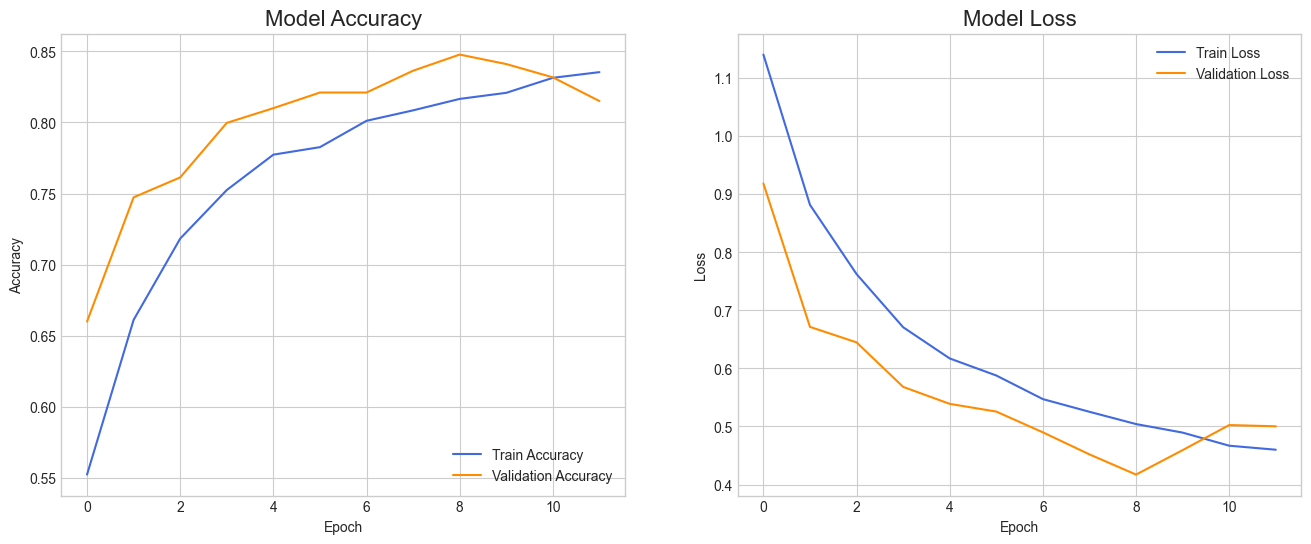

In [ ]:
# Plot training & validation accuracy values
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
ax1.set_title('Model Accuracy', fontsize=16)
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')

# Plot training & validation loss values
ax2.plot(history.history['loss'], label='Train Loss', color='royalblue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
ax2.set_title('Model Loss', fontsize=16)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

plt.show()

### Analysis of Plots:

- Accuracy Graph (Left): The training accuracy (blue) climbs steadily and reaches nearly 100%, while the validation accuracy (orange) platues around 82%. This divergence indicates that the model is beginning to overfit. It has learned the training data so well that it struggles to generalize to new, unseen data.
- Loss Graph (Right): Similarly, the training loss drops close to zero, while the validation loss decreases initially but then starts to slowly increase. This is another clear sign of overfitting.

### 5.3 Summary of Performance

The CNN model successfully learned to recognize images from the dataset, achieving a final test accuracy of 82.07%. This demonstrates that the chosen architecture, with three convolutional layers, is capable of extracting meaningful features for classifying natural scenes.

However, the analysis of the learning curves reveals significant overfitting. While the model performs exceptionally well on the data it has seen, its performance on new data is limited. For future work, several techniques could be implemented to combat overfitting and improve generalization:

- Data Augmentation: Applying random transformations (like rotation, zoom, and flips) to the training images to create more variety.
- Dropout: Adding dropout layers to the network, which randomly deactivates neurons during training to prevent co-dependency.
- Transfer Learning: Using a pre-trained model (like VGG16 or ResNet) and fine-tuning it on our dataset, which can often yield better results with less training time.

Overall, the project successfully fulfilled its objective of building and training a CNN for image recognition, providing a solid baseline performance and clear next steps for improvement. 🚀

## 6: References

- Dataset: P. B., Puneet. (2018). Intel Image Classification. Kaggle. Retrieved from https://www.kaggle.com/datasets/puneet6060/intel-image-classification

- TensorFlow & Keras: Chollet, F. et al. (2015). Keras. GitHub. Retrieved from https://github.com/keras-team/keras

- Matplotlib: Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90-95.